In [1]:
setwd('/home/rstudio/analysis/')

In [2]:
library(Seurat)
library(ggplot2)
library(sctransform)
library(scRepertoire)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [3]:
patient4.data <- Read10X(data.dir = "/home/rstudio/run071/run071_RSEC_MolsPerCell_MEX")
patient4 <- CreateSeuratObject(counts = patient4.data, project = "patient4", min.cells = 3, min.features = 200)

In [4]:
#QC #calculates the percentage of counts originating from a set of features #mitochondrial contamination
patient4[["percent.mt"]] <- PercentageFeatureSet(patient4, pattern = "^MT-")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


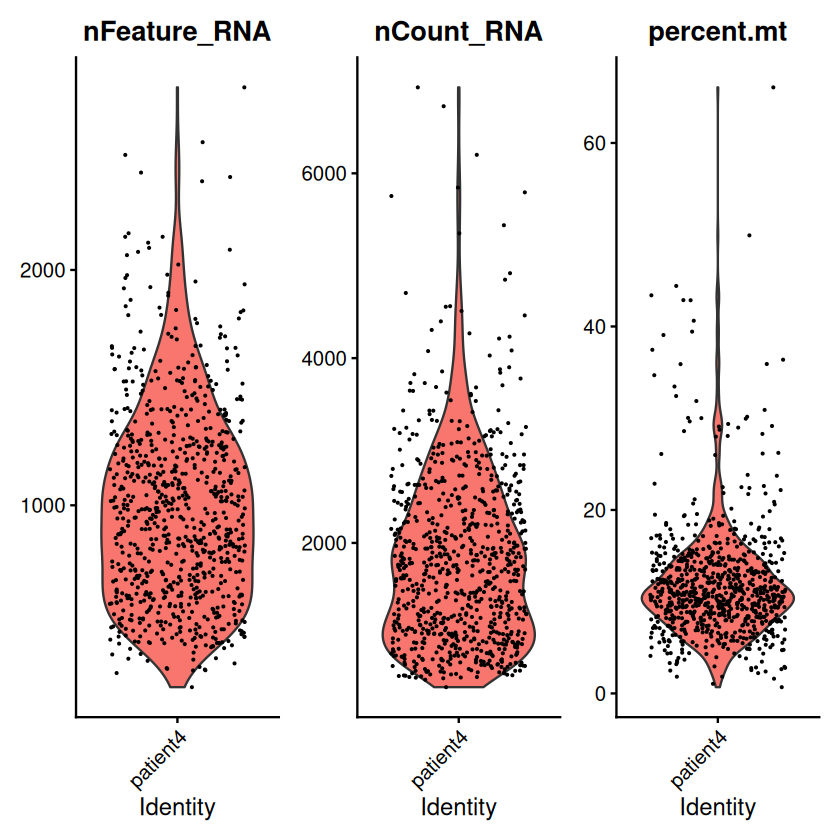

In [5]:
# Violin Plot
VlnPlot(patient4, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

### SCTransform

In [6]:
# run sctransform
# this single command replaces NormalizeData(), ScaleData(), and FindVariableFeatures() #install glmGamPoi
patient4_transform <- SCTransform(patient4, verbose = FALSE) #No filtering based on mito. contamination

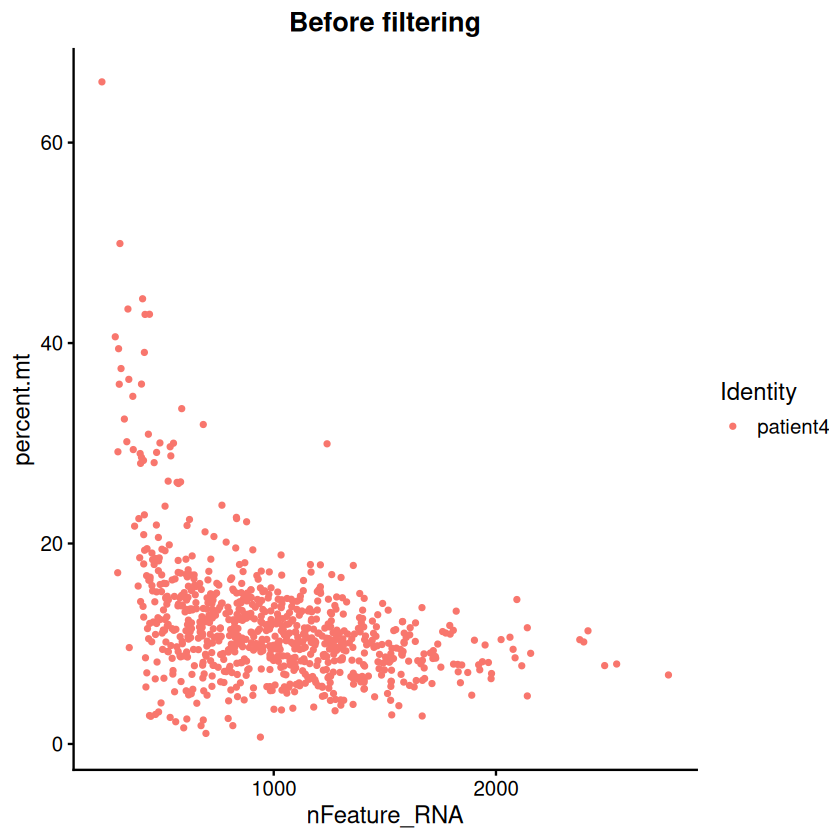

In [7]:
# before filtering
#VlnPlot(patient4, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient4, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("Before filtering")

In [8]:
patient4_transform <- subset(patient4_transform, subset = percent.mt < 20) # kept 20 to avoid aggressive filt

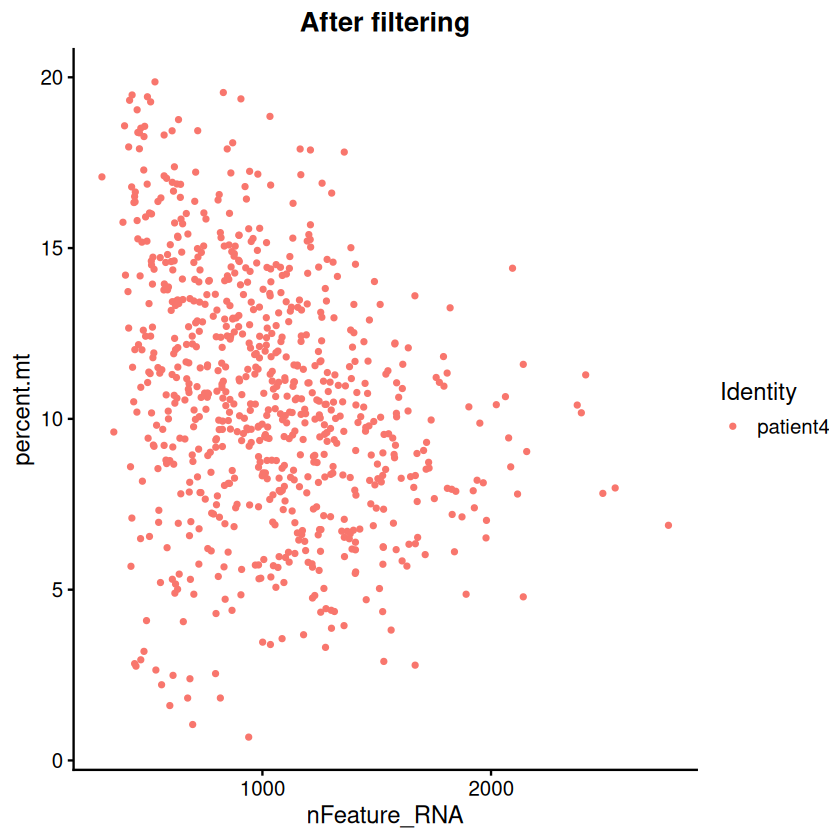

In [9]:
# after filtering
#VlnPlot(patient4_transform, features = c("nFeature_RNA", "percent.mt"), pt.size = 0.1)

FeatureScatter(patient4_transform, feature1 = "nFeature_RNA", feature2 = "percent.mt") +
  ggtitle("After filtering")

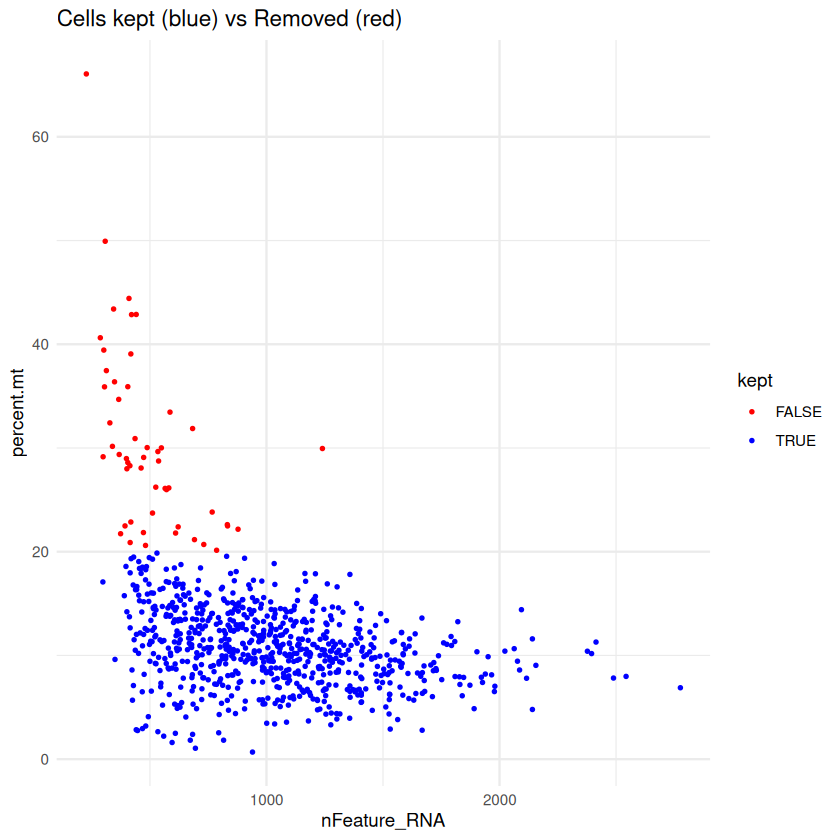

In [10]:
# Retained - Blue, Removed - Red
df <- FetchData(patient4, vars = c("nFeature_RNA", "percent.mt"))
df$kept <- rownames(df) %in% colnames(patient4_transform)

ggplot(df, aes(x = nFeature_RNA, y = percent.mt, color = kept)) +
  geom_point(size = 0.5) +
  scale_color_manual(values = c("red", "blue")) +
  theme_minimal() +
  labs(title = "Cells kept (blue) vs Removed (red)")

### PCA, UMAP, Shared nearest neighbour, Clustering

In [11]:
patient4_transform <- RunPCA(patient4_transform)
patient4_transform <- RunUMAP(patient4_transform, dims = 1:30)
patient4_transform <- FindNeighbors(patient4_transform, dims = 1:30)
patient4_transform <- FindClusters(patient4_transform, resolution = 0.5)

PC_ 1 
Positive:  DUSP4, LINC-PINT, PDE3B, SIK3, CBLB, PTPN22, NFAT5, PRKCH, RABGAP1L, HLA-DRB1 
	   CEMIP2, MALAT1, ITGAE, BICDL1, LYST, RNF19A, CHST11, NEAT1, ATXN1, RGS1 
	   MYO7A, FYN, AKAP13, PDE7A, TOX, PRDM1, PPP1R16B, GGA2, BRAF, AHI1 
Negative:  VIM, EEF1A1, FTH1, RPL34, TPT1, RPS29, KLF2, RPS6, FOS, RPS27 
	   RPL27A, ANXA1, HEXIM1, KLF6, RPS18, RPL39, RPS12, RPS3, RPL10, RPS4X 
	   IL7R, ARL4C, RPL3, PABPC1, BTG1, RPS8, ZFP36, MT-ND2, RPLP2, IRF2BP2 
PC_ 2 
Positive:  DUSP4, HSPA1A, HLA-DRB1, CD74, HSPH1, HLA-DRA, RGS1, CCL5, NKG7, ID2 
	   HLA-DRB5, HLA-DPB1, HSP90AA1, TRBC1, GAPDH, CD8A, PRDM1, CCND2, VCAM1, CXCL13 
	   ACTB, GZMB, BHLHE40, GZMA, AKAP5, APOBEC3C, DNAJA1, PHLDA1, HLA-DPA1, RHOB 
Negative:  MALAT1, LINC-PINT, TALAM1, SIK3, IL7R, CDC42SE2, EML4, ARHGAP15, ARHGAP26, MT-ND2 
	   BRAF, SYNE2, LINC01619, NFAT5, KLF2, PITPNC1, MT-ND1, PDE3B, SPOCK2, TCF7 
	   CHD2, AKT3, ZSWIM6, NEAT1, ADK, NOL10, SETD2, OSBPL8, CRY1, DNAJC1 
PC_ 3 
Positive:  SGK1, CXCL8, KLF4, 

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 750
Number of edges: 39692

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7957
Number of communities: 4
Elapsed time: 0 seconds


In [12]:
#checking metadata
colnames(patient4_transform@meta.data)

[1] "orig.ident"      "nCount_RNA"      "nFeature_RNA"    "percent.mt"     
[5] "nCount_SCT"      "nFeature_SCT"    "SCT_snn_res.0.5" "seurat_clusters"

## scRepertoire on patient 4

In [13]:
library(scRepertoire)
S2 <- read.delim("/home/rstudio/run071/run071-nsclc-4_VDJ_Dominant_Contigs_AIRR.tsv", sep = "\t", header = TRUE, stringsAsFactors = FALSE)

contig_list_2 <- list(S2)
contig_list_2 <- loadContigs(input = S2, 
                           format = "AIRR")

#converting columns in TCR data to character (string).
contig_list <- lapply(contig_list, function(df) {
  for (col in c("cdr3_nt", "cdr3", "chain", "barcode", "v_gene", "j_gene", "d_gene", "c_gene")) {
    if (col %in% names(df)) df[[col]] <- as.character(df[[col]])
  }
  df
})

In [14]:
combined.TCR_p4 <- combineTCR(
  contig_list_2,
  samples = c("P4_S1"),
  removeNA = TRUE,
  removeMulti = FALSE,
  filterMulti = FALSE
)

# output = a list of contig data frames that will be reduced to the reads associated with a single cell barcode. It will also combine the multiple reads into clone calls by either the nucleotide sequence (CTnt), amino acid sequence (CTaa), the VDJC gene sequence (CTgene), or the combination of the nucleotide and gene sequence (CTstrict).
#check
head(combined.TCR_p4[[1]])

,barcode,sample,TCR1,cdr3_aa1,cdr3_nt1,TCR2,cdr3_aa2,cdr3_nt2,CTgene,CTnt,CTaa,CTstrict
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,P4_S1_1002101,P4_S1,TRAV19*01.TRAJ27*01.TRAC,CAPTPMQANQP,TGTGCCCCAACACCAATGCAGGCAAATCAACCTTT,TRBV11-2*01.NA.TRBJ1-1*01.TRBC1,CASSLHPVKGWEAFF,TGTGCCAGCAGCTTACATCCGGTTAAAGGATGGGAAGCTTTCTTT,TRAV19*01.TRAJ27*01.TRAC_TRBV11-2*01.NA.TRBJ1-1*01.TRBC1,TGTGCCCCAACACCAATGCAGGCAAATCAACCTTT_TGTGCCAGCAGCTTACATCCGGTTAAAGGATGGGAAGCTTTCTTT,CAPTPMQANQP_CASSLHPVKGWEAFF,TRAV19*01.TRAJ27*01.TRAC;TGTGCCCCAACACCAATGCAGGCAAATCAACCTTT_TRBV11-2*01.NA.TRBJ1-1*01.TRBC1;TGTGCCAGCAGCTTACATCCGGTTAAAGGATGGGAAGCTTTCTTT
3,P4_S1_10279593,P4_S1,TRAV13-2*01.TRAJ26*01.TRAC,CAENTRGRRSEFCL,TGTGCAGAGAATACGAGGGGTAGGAGGTCAGAATTTTGTCTTT,TRBV6-2*01.TRBD1*01.TRBJ1-1*01.TRBC1,CASEPGGDLAEAFF,TGTGCCAGCGAACCCGGGGGCGATTTGGCTGAAGCTTTCTTT,TRAV13-2*01.TRAJ26*01.TRAC_TRBV6-2*01.TRBD1*01.TRBJ1-1*01.TRBC1,TGTGCAGAGAATACGAGGGGTAGGAGGTCAGAATTTTGTCTTT_TGTGCCAGCGAACCCGGGGGCGATTTGGCTGAAGCTTTCTTT,CAENTRGRRSEFCL_CASEPGGDLAEAFF,TRAV13-2*01.TRAJ26*01.TRAC;TGTGCAGAGAATACGAGGGGTAGGAGGTCAGAATTTTGTCTTT_TRBV6-2*01.TRBD1*01.TRBJ1-1*01.TRBC1;TGTGCCAGCGAACCCGGGGGCGATTTGGCTGAAGCTTTCTTT
6,P4_S1_10311423,P4_S1,TRAV21*01.TRAJ15*01.TRAC,CAVVNQAGTALIF,TGTGCTGTAGTTAACCAGGCAGGAACTGCTCTGATCTTT,TRBV11-2*01.TRBD2*02.TRBJ1-2*01.TRBC1,CASSPYPGGGYTF,TGTGCCAGCAGCCCATACCCGGGAGGAGGCTACACCTTC,TRAV21*01.TRAJ15*01.TRAC_TRBV11-2*01.TRBD2*02.TRBJ1-2*01.TRBC1,TGTGCTGTAGTTAACCAGGCAGGAACTGCTCTGATCTTT_TGTGCCAGCAGCCCATACCCGGGAGGAGGCTACACCTTC,CAVVNQAGTALIF_CASSPYPGGGYTF,TRAV21*01.TRAJ15*01.TRAC;TGTGCTGTAGTTAACCAGGCAGGAACTGCTCTGATCTTT_TRBV11-2*01.TRBD2*02.TRBJ1-2*01.TRBC1;TGTGCCAGCAGCCCATACCCGGGAGGAGGCTACACCTTC
8,P4_S1_10627379,P4_S1,TRAV29/DV5*01.TRAJ47*01.TRAC,CAASRYGNKLVF,TGTGCAGCAAGCAGATATGGAAACAAACTGGTCTTT,TRBV27*01.TRBD2*02.TRBJ2-2*01.TRBC2,CASNFQLAGVGGELFF,TGTGCCAGCAACTTCCAACTAGCGGGAGTTGGCGGGGAGCTGTTTTTT,TRAV29/DV5*01.TRAJ47*01.TRAC_TRBV27*01.TRBD2*02.TRBJ2-2*01.TRBC2,TGTGCAGCAAGCAGATATGGAAACAAACTGGTCTTT_TGTGCCAGCAACTTCCAACTAGCGGGAGTTGGCGGGGAGCTGTTTTTT,CAASRYGNKLVF_CASNFQLAGVGGELFF,TRAV29/DV5*01.TRAJ47*01.TRAC;TGTGCAGCAAGCAGATATGGAAACAAACTGGTCTTT_TRBV27*01.TRBD2*02.TRBJ2-2*01.TRBC2;TGTGCCAGCAACTTCCAACTAGCGGGAGTTGGCGGGGAGCTGTTTTTT
10,P4_S1_10742731,P4_S1,TRAV9-2*01.TRAJ43*01.TRAC,CALGEGDMRF,TGTGCTCTGGGGGAGGGTGACATGCGCTTT,TRBV11-2*01.TRBD1*01.TRBJ2-7*01.TRBC2,CASSRGARVAAYEQYF,TGTGCCAGCAGCCGAGGGGCGAGGGTGGCCGCCTACGAGCAGTACTTC,TRAV9-2*01.TRAJ43*01.TRAC_TRBV11-2*01.TRBD1*01.TRBJ2-7*01.TRBC2,TGTGCTCTGGGGGAGGGTGACATGCGCTTT_TGTGCCAGCAGCCGAGGGGCGAGGGTGGCCGCCTACGAGCAGTACTTC,CALGEGDMRF_CASSRGARVAAYEQYF,TRAV9-2*01.TRAJ43*01.TRAC;TGTGCTCTGGGGGAGGGTGACATGCGCTTT_TRBV11-2*01.TRBD1*01.TRBJ2-7*01.TRBC2;TGTGCCAGCAGCCGAGGGGCGAGGGTGGCCGCCTACGAGCAGTACTTC
13,P4_S1_10800031,P4_S1,TRAV14/DV4*01.TRAJ29*01.TRAC,CAMREGPGNTPLVF,TGTGCAATGAGAGAGGGCCCAGGAAACACACCTCTTGTCTTT,TRBV20-1*01.TRBD1*01.TRBJ2-7*01.TRBC2,CSVDRAYEQYF,TGCAGTGTTGACAGGGCCTACGAGCAGTACTTC,TRAV14/DV4*01.TRAJ29*01.TRAC_TRBV20-1*01.TRBD1*01.TRBJ2-7*01.TRBC2,TGTGCAATGAGAGAGGGCCCAGGAAACACACCTCTTGTCTTT_TGCAGTGTTGACAGGGCCTACGAGCAGTACTTC,CAMREGPGNTPLVF_CSVDRAYEQYF,TRAV14/DV4*01.TRAJ29*01.TRAC;TGTGCAATGAGAGAGGGCCCAGGAAACACACCTCTTGTCTTT_TRBV20-1*01.TRBD1*01.TRBJ2-7*01.TRBC2;TGCAGTGTTGACAGGGCCTACGAGCAGTACTTC


## combineExpression() on patient 4

In [15]:
#check
head(combined.TCR_p4[[1]]$barcode)
rownames(patient4_transform@meta.data)
## to see if the headers match here

[1] "P4_S1_1002101"  "P4_S1_10279593" "P4_S1_10311423" "P4_S1_10627379"
[5] "P4_S1_10742731" "P4_S1_10800031"

[1] "111840"   "146164"   "166368"   "205244"   "289640"   "480269"  
  [7] "544629"   "568064"   "679531"   "731374"   "749304"   "755182"  
 [13] "766428"   "768329"   "985049"   "1002101"  "1136612"  "1185364" 
 [19] "1328663"  "1359810"  "1379377"  "1487305"  "1552703"  "1709118" 
 [25] "1805606"  "1849226"  "2121737"  "2125503"  "2247955"  "2270706" 
 [31] "2308106"  "2378866"  "2414277"  "2415746"  "2468812"  "2506961" 
 [37] "2854419"  "2911169"  "2937833"  "2959747"  "3036569"  "3076911" 
 [43] "3176029"  "3445984"  "3629500"  "3685303"  "3760480"  "3784046" 
 [49] "3787374"  "3836824"  "3892288"  "3937923"  "3968578"  "3996641" 
 [55] "4037966"  "4062107"  "4138893"  "4140304"  "4197908"  "4206466" 
 [61] "4235267"  "4366037"  "4377508"  "4389901"  "4398520"  "4517196" 
 [67] "4575560"  "4788051"  "4873590"  "5002757"  "5017343"  "5186100" 
 [73] "5262173"  "5375822"  "5390999"  "5402514"  "5508370"  "5772902" 
 [79] "5871385"  "6087978"  "6146148"  "6212271"  "6293746"  "6410289" 
 [85] "6505853"  "6580476"  "6656322"  "6703908"  "6760320"  "6797139" 
 [91] "6976674"  "7024331"  "7127271"  "7306090"  "7372679"  "7633965" 
 [97] "7829958"  "7979596"  "7998332"  "8426339"  "8428996"  "8529903" 
[103] "8600333"  "8600357"  "8744575"  "8859261"  "8977779"  "9145674" 
[109] "9160359"  "9165137"  "9458989"  "9515008"  "9548509"  "9620387" 
[115] "9653855"  "9893232"  "10136541" "10279593" "10300542" "10311423"
[121] "10627379" "10742731" "10761606" "10800031" "10802248" "10954429"
[127] "11029548" "11040960" "11104425" "11108353" "11121537" "11154791"
[133] "11173368" "11226389" "11298444" "11371282" "11406962" "11416165"
[139] "11602137" "11654897" "11832300" "11874225" "11874623" "11999581"
[145] "12097957" "12129601" "12154522" "12232277" "12270586" "12494215"
[151] "12558134" "12649951" "12692487" "12922590" "12936327" "12967133"
[157] "13071638" "13088922" "13239049" "13357146" "13362584" "13601365"
[163] "13687458" "13758721" "13778008" "13875001" "13922489" "14100746"
[169] "14242205" "14242226" "14362282" "14415218" "14591798" "14660060"
[175] "14691783" "14742924" "14744745" "14758573" "15063661" "15138491"
[181] "15222476" "15338524" "15340335" "15378877" "15471631" "15752393"
[187] "15818413" "15970753" "16056854" "16173741" "16176701" "16270295"
[193] "16352315" "16548528" "16577601" "16759851" "16836657" "17004682"
[199] "17063375" "17130292" "17230031" "17389449" "17425559" "17473659"
[205] "17519495" "17714145" "17734635" "17761914" "17821025" "17855936"
[211] "17858741" "17935841" "17936509" "17974999" "17977074" "18068347"
[217] "18084296" "18169324" "18251983" "18625187" "18706962" "18710410"
[223] "18766182" "18766597" "18792687" "18805778" "18972561" "19000948"
[229] "19011507" "19150351" "19286688" "19354448" "19389751" "19483736"
[235] "19501254" "19629235" "19763710" "19773806" "19810788" "20066104"
[241] "20104277" "20117205" "20120663" "20139043" "20256942" "20280352"
[247] "20379958" "20444371" "20454666" "20494993" "20531642" "20806164"
[253] "20939274" "20952398" "21185839" "21232471" "21492610" "21768142"
[259] "21795217" "21796427" "21941027" "21958617" "22029866" "22077703"
[265] "22190712" "22217905" "22250135" "22315481" "22350954" "22376475"
[271] "22422670" "22454690" "22485903" "22575775" "22612090" "22660917"
[277] "22733773" "22769814" "22865233" "22965330" "22968086" "23090430"
[283] "23174042" "23260481" "23356664" "23485777" "23551454" "23585581"
[289] "23624179" "23687524" "23747977" "23856659" "23920512" "24004590"
[295] "24196652" "24209163" "24340450" "24352399" "24375468" "24400398"
[301] "24446637" "24509986" "24547483" "24621916" "24686765" "25042799"
[307] "25062072" "25180230" "25279786" "25384037" "25390264" "25517943"
[313] "25520887" "25615116" "25618986" "25631822" "25674740" "25695775"
[319] "25751808" "25781651" "25804735" "25869159" "25911667" "25950014"
[325] "25982546" "26124284" "26178656" "26458394" "26461130" "26640264"
[331] "26673498" "26712418" "26713148" "26

In [16]:
# Matching the barcodes = removing the 'PS'
combined.TCR_p4 <- lapply(combined.TCR_p4, function(x) {
  x$barcode <- gsub("P4_S1_", "", x$barcode)
  return(x)
})

In [17]:
#check again after removing extra letters
head(colnames(patient4_transform@meta.data))
colnames(combined.TCR_p4[[1]])
head(combined.TCR_p4[[1]]$barcode, 10)
barcodes_tcr <- unlist(lapply(combined.TCR_p4, function(x) x$barcode))
head(barcodes_tcr, 10)
barcodes_seurat <- colnames(patient4_transform)
head(barcodes_seurat, 10)

[1] "orig.ident"   "nCount_RNA"   "nFeature_RNA" "percent.mt"   "nCount_SCT"  
[6] "nFeature_SCT"

[1] "barcode"  "sample"   "TCR1"     "cdr3_aa1" "cdr3_nt1" "TCR2"    
 [7] "cdr3_aa2" "cdr3_nt2" "CTgene"   "CTnt"     "CTaa"     "CTstrict"

[1] "1002101"  "10279593" "10311423" "10627379" "10742731" "10800031"
 [7] "10954429" "11029548" "11040960" "11104425"

P4_S11     P4_S12     P4_S13     P4_S14     P4_S15     P4_S16     P4_S17 
 "1002101" "10279593" "10311423" "10627379" "10742731" "10800031" "10954429" 
    P4_S18     P4_S19    P4_S110 
"11029548" "11040960" "11104425"

[1] "111840" "146164" "166368" "205244" "289640" "480269" "544629" "568064"
 [9] "679531" "731374"

In [18]:
sce_patient4 <- combineExpression(
  combined.TCR_p4,
  patient4_transform,
  cloneCall = "CTgene",
  group.by = "sample",
  proportion = TRUE,
  cloneSize = c(Single = 1, Small = 5, Medium = 20, Large = 100, Hyperexpanded = 500) # cloneSize doesn't seem to make a difference later downstream
)

In [19]:
# check the res.
sce_patient4
colnames(sce_patient4@meta.data)

An object of class Seurat 
30351 features across 750 samples within 2 assays 
Active assay: SCT (13866 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 2 dimensional reductions calculated: pca, umap

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "percent.mt"      
 [5] "nCount_SCT"       "nFeature_SCT"     "SCT_snn_res.0.5"  "seurat_clusters" 
 [9] "CTgene"           "CTnt"             "CTaa"             "CTstrict"        
[13] "clonalProportion" "clonalFrequency"  "cloneSize"

In [20]:
setwd('/home/rstudio/analysis/saved_objects_new')
getwd()

#export

saveRDS(patient4, "patient4.rds")
saveRDS(patient4_transform, "patient4_transform.rds")
saveRDS(combined.TCR_p4, "combined_TCR_p4.rds")

[1] "/home/rstudio/analysis/saved_objects_new"